# All-NBA Team Prediction using Multinomial Logistic Regression

Predicting which players make All-NBA teams (1st, 2nd, 3rd) using NBA player statistics from 2011-2025.

**4-class target:**
- 0 = None
- 1 = 3rd Team
- 2 = 2nd Team
- 3 = 1st Team

## 1. Data Loading & Initial Exploration

In [57]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

In [30]:
df_full = pd.read_csv('data/combined/all_years_combined_with_lebron.csv')
df_full.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Awards,Player-additional,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,All_NBA_Label,All_NBA_Target,Season_End_Year,LEBRON,O-LEBRON,D-LEBRON,WAR
0,104.0,Arron Afflalo,25.0,DEN,SG,69.0,69.0,2324.0,312.0,627.0,0.498,105.0,248.0,0.423,207.0,379.0,0.546,0.581,138.0,163.0,0.847,45.0,206.0,251.0,168.0,34.0,31.0,71.0,153.0,867.0,0.0,NaN,afflaar01,13.6,0.620,0.396,0.260,2.3,9.9,6.2,10.9,0.7,1.0,9.2,14.8,4.8,1.4,6.2,0.128,1.7,-0.3,1.4,2.0,NaN,0,2011,0.44,1.01,-0.57,4.27
1,33.0,Ray Allen,35.0,BOS,SG,80.0,80.0,2890.0,480.0,978.0,0.491,168.0,378.0,0.444,312.0,600.0,0.520,0.577,193.0,219.0,0.881,51.0,223.0,274.0,219.0,77.0,16.0,117.0,147.0,1321.0,0.0,AS,allenra02,16.4,0.615,0.387,0.224,2.3,9.0,5.8,12.7,1.4,0.4,9.8,19.8,5.8,4.2,10.0,0.166,2.3,0.6,2.9,3.6,NaN,0,2011,1.02,0.61,0.41,6.45
2,165.0,Tony Allen,29.0,MEM,SG,72.0,31.0,1494.0,251.0,492.0,0.510,4.0,23.0,0.174,247.0,469.0,0.527,0.514,137.0,182.0,0.753,70.0,123.0,193.0,104.0,129.0,44.0,86.0,161.0,643.0,0.0,DPOY-46MOY-11DEF2,allento01,18.4,0.562,0.047,0.370,5.5,9.9,7.7,10.9,4.5,2.4,13.1,19.9,2.0,2.7,4.7,0.152,0.1,3.5,3.6,2.1,NaN,0,2011,1.72,-0.37,2.09,4.03
3,214.0,Al-Farouq Aminu,20.0,LAC,SF,81.0,14.0,1452.0,160.0,406.0,0.394,45.0,143.0,0.315,115.0,263.0,0.437,0.450,92.0,119.0,0.773,75.0,192.0,267.0,60.0,59.0,25.0,103.0,121.0,457.0,0.0,NaN,aminual01,9.6,0.499,0.352,0.293,6.1,15.4,10.8,6.4,2.1,1.3,18.3,17.3,-0.8,1.4,0.7,0.022,-2.7,-0.1,-2.8,-0.3,NaN,0,2011,-2.11,-2.35,0.23,0.17
4,310.0,Lou Amundson,28.0,GSW,PF,46.0,7.0,691.0,83.0,183.0,0.454,0.0,0.0,NaN,83.0,183.0,0.454,0.454,34.0,87.0,0.391,81.0,104.0,185.0,17.0,14.0,33.0,24.0,87.0,200.0,0.0,NaN,amundlo01,11.5,0.452,0.000,0.475,13.0,17.4,15.2,3.5,1.0,3.6,9.8,15.7,0.2,0.5,0.6,0.044,-3.1,-1.4,-4.5,-0.4,NaN,0,2011,-1.99,-2.16,0.16,0.14


In [31]:
df_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 5214 entries, 0 to 5213
Data columns (total 60 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rk                 5214 non-null   float64
 1   Player             5214 non-null   str    
 2   Age                5214 non-null   float64
 3   Team               5214 non-null   str    
 4   Pos                5214 non-null   str    
 5   G                  5214 non-null   float64
 6   GS                 5214 non-null   float64
 7   MP                 5214 non-null   float64
 8   FG                 5214 non-null   float64
 9   FGA                5214 non-null   float64
 10  FG%                5214 non-null   float64
 11  3P                 5214 non-null   float64
 12  3PA                5214 non-null   float64
 13  3P%                4961 non-null   float64
 14  2P                 5214 non-null   float64
 15  2PA                5214 non-null   float64
 16  2P%                5214 non-null   

## 2. Target Variable Analysis

In [32]:
#Target distribution

print("All_NBA_Target value counts: ")
print(df_full['All_NBA_Target'].value_counts().sort_index())

print("*" * 50)

print('All_NBA_Label value counts:')
print(df_full['All_NBA_Label'].value_counts())

All_NBA_Target value counts: 
All_NBA_Target
0    5025
1      59
2      65
3      65
Name: count, dtype: int64
**************************************************
All_NBA_Label value counts:
All_NBA_Label
NBA1    65
NBA2    65
NBA3    59
Name: count, dtype: int64


In [33]:
# sanity check
allnba_per_season = df_full[df_full['All_NBA_Target'] > 0].groupby('Season_End_Year')['All_NBA_Target'].count()
print(allnba_per_season.to_string())

Season_End_Year
2011    11
2012    14
2013    14
2014    12
2015    11
2016    11
2017    11
2018    11
2019    14
2020    13
2021    13
2022    13
2023    13
2024    14
2025    14


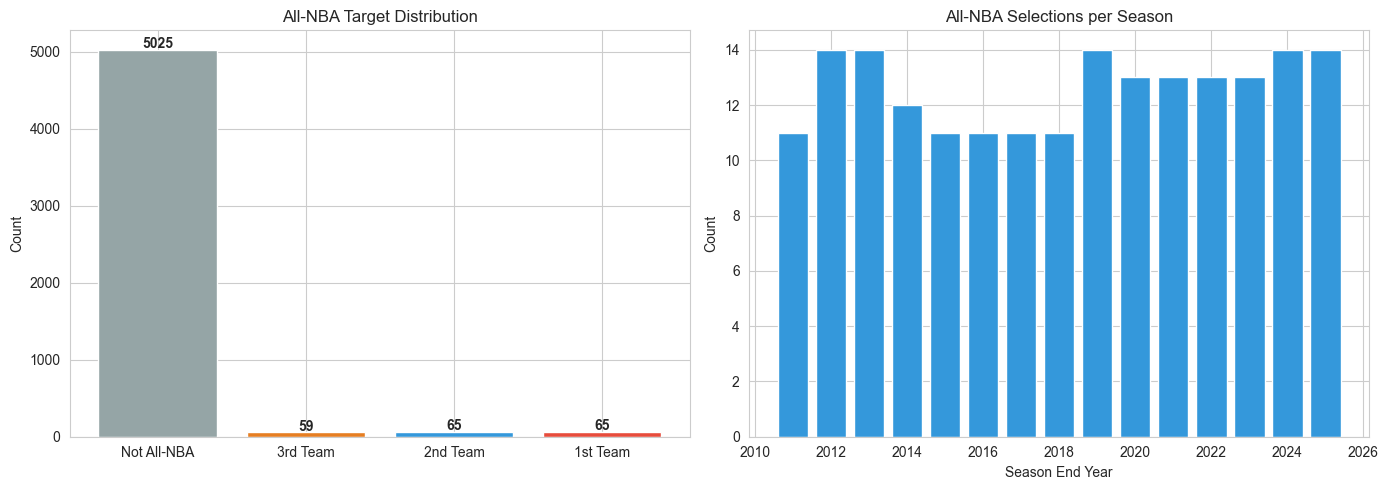

In [34]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

target_counts = df_full['All_NBA_Target'].value_counts().sort_index()
labels = ['Not All-NBA', '3rd Team', '2nd Team', '1st Team']
colors = ['#95a5a6', '#e67e22', '#3498db', '#e74c3c']

axes[0].bar(labels, target_counts.values, color=colors)
axes[0].set_title('All-NBA Target Distribution')
axes[0].set_ylabel('Count')

for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, str(v), ha = 'center', fontweight = 'bold')

allnba_by_year = df_full[df_full['All_NBA_Target'] > 0].groupby('Season_End_Year')['All_NBA_Target'].count()
axes[1].bar(allnba_by_year.index, allnba_by_year.values, color='#3498db')
axes[1].set_title('All-NBA Selections per Season')
axes[1].set_xlabel('Season End Year')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. Feature Exploration

In [35]:
# Missing values

missing = df_full.isnull().sum()
missing_pct = (missing / len(df_full) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

print(missing_df[missing_df['Missing Count'] > 0])

               Missing Count  Missing %
3P%                      253       4.85
FT%                        1       0.02
Awards                  4436      85.08
All_NBA_Label           5025      96.38


In [36]:
# Compare key stats: All-NBA vs Non All-NBA players

key_stats = ['PTS', 'TRB', 'AST', 'STL', 'BLK', 'PER', 'WS', 'BPM', 'VORP', 'LEBRON', 'WAR', 'MP', 'G']
comparison = df_full.groupby('All_NBA_Target')[key_stats].mean().round(2)
comparison.index = ['Not All-NBA', '3rd Team', '2nd Team', '1st Team'][:len(comparison)]

comparison.T

,Not All-NBA,3rd Team,2nd Team,1st Team
PTS,592.79,1514.68,1670.88,1930.42
TRB,246.07,530.97,517.02,585.46
AST,131.61,376.25,389.80,436.78
STL,43.70,91.73,82.48,102.09
BLK,27.88,52.83,55.86,63.80
PER,13.71,21.73,23.94,26.96
WS,2.77,8.96,10.12,12.24
BPM,-0.85,4.31,5.58,8.12
VORP,0.60,3.92,4.67,6.42
LEBRON,-0.46,3.06,3.57,5.10


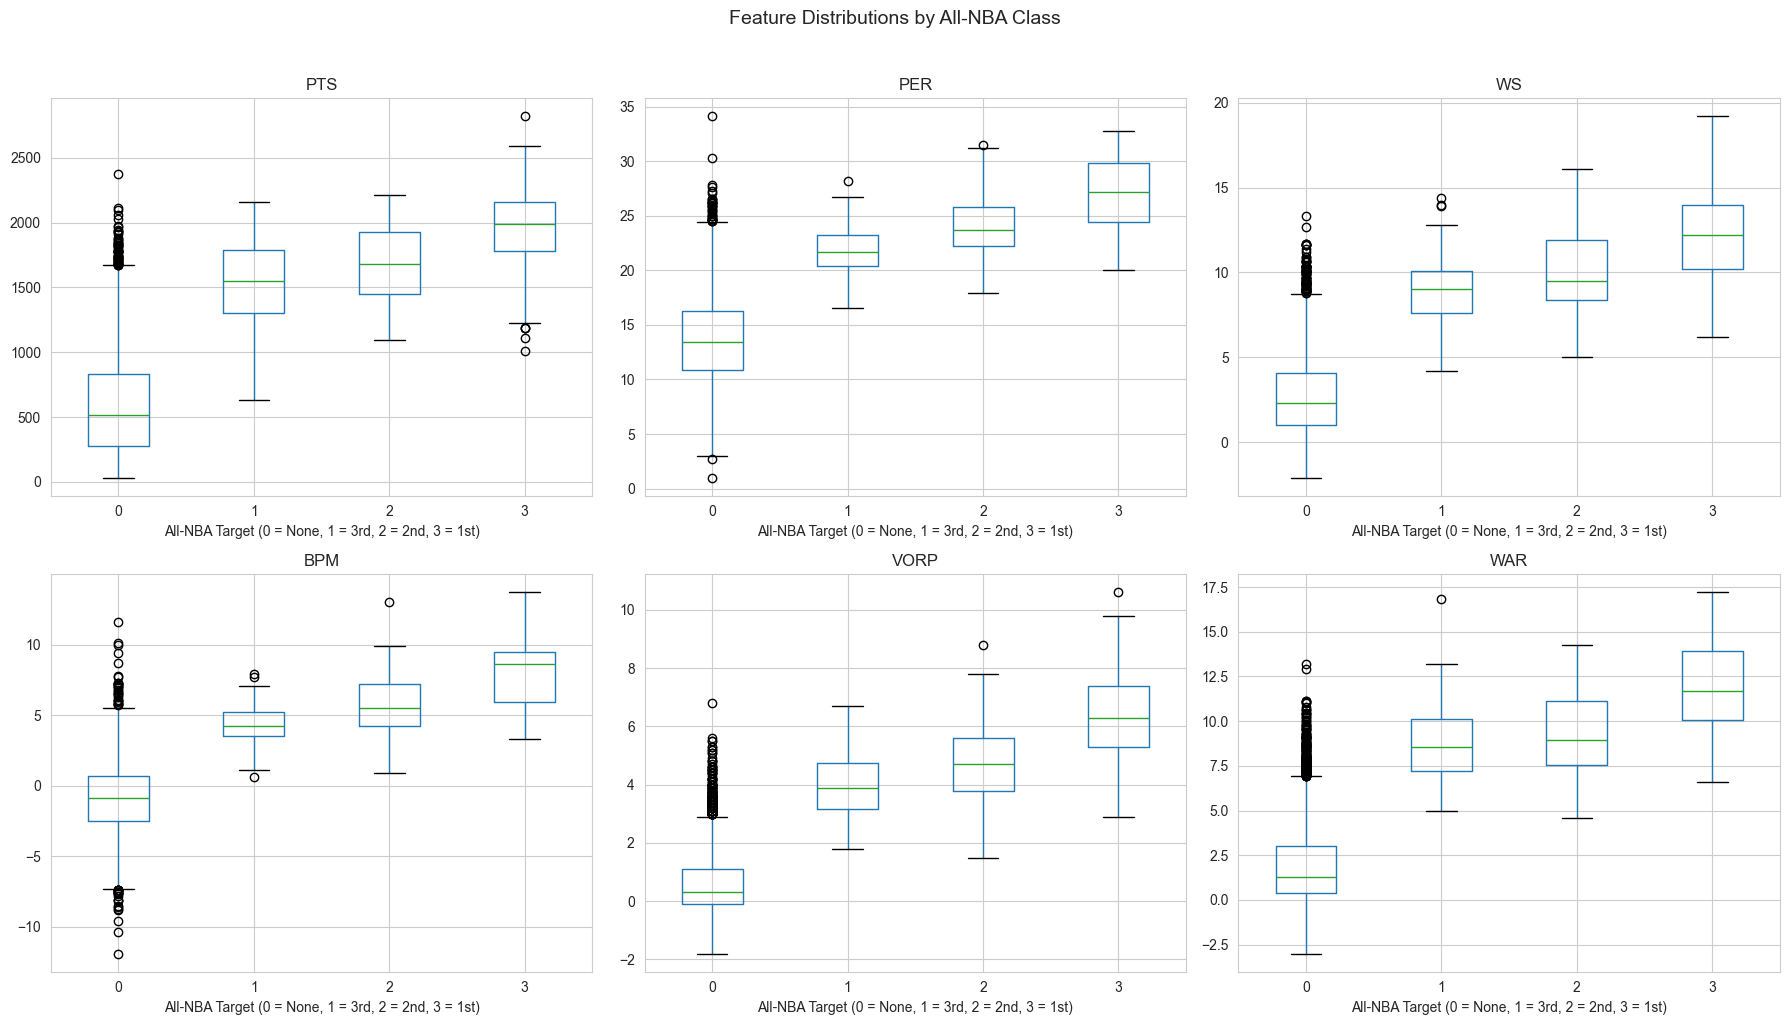

In [37]:
# Box plots of key features by All-NBA status

fig, axes = plt.subplots(2, 3, figsize = (18, 10))
plot_features = ['PTS', 'PER', 'WS', 'BPM', 'VORP', 'WAR']

for ax, feat in zip(axes.ravel(), plot_features):
    df_full.boxplot(column = feat, by = 'All_NBA_Target', ax = ax)
    ax.set_title(feat)
    ax.set_xlabel('All-NBA Target (0 = None, 1 = 3rd, 2 = 2nd, 3 = 1st)')

plt.suptitle('Feature Distributions by All-NBA Class', fontsize = 14, y = 1.02)
plt.tight_layout()
plt.show()

## 4. Data Preparation


In [38]:
#load basic data

df = pd.read_csv('data/model_datasets/basic_dataset.csv')
df.head()

,Team,Pos,Age,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Season_End_Year,All_NBA_Target
0,DEN,SG,25.0,69.0,69.0,2324.0,312.0,627.0,0.498,105.0,248.0,0.423,207.0,379.0,0.546,0.581,138.0,163.0,0.847,45.0,206.0,251.0,168.0,34.0,31.0,71.0,153.0,867.0,0.0,2011,0
1,BOS,SG,35.0,80.0,80.0,2890.0,480.0,978.0,0.491,168.0,378.0,0.444,312.0,600.0,0.520,0.577,193.0,219.0,0.881,51.0,223.0,274.0,219.0,77.0,16.0,117.0,147.0,1321.0,0.0,2011,0
2,MEM,SG,29.0,72.0,31.0,1494.0,251.0,492.0,0.510,4.0,23.0,0.174,247.0,469.0,0.527,0.514,137.0,182.0,0.753,70.0,123.0,193.0,104.0,129.0,44.0,86.0,161.0,643.0,0.0,2011,0
3,LAC,SF,20.0,81.0,14.0,1452.0,160.0,406.0,0.394,45.0,143.0,0.315,115.0,263.0,0.437,0.450,92.0,119.0,0.773,75.0,192.0,267.0,60.0,59.0,25.0,103.0,121.0,457.0,0.0,2011,0
4,GSW,PF,28.0,46.0,7.0,691.0,83.0,183.0,0.454,0.0,0.0,NaN,83.0,183.0,0.454,0.454,34.0,87.0,0.391,81.0,104.0,185.0,17.0,14.0,33.0,24.0,87.0,200.0,0.0,2011,0


In [39]:
#metadata, feature/target split

df_meta = df_full[['Player', 'Team', 'Pos', 'Season_End_Year', 'All_NBA_Label', 'All_NBA_Target']].copy()
TARGET = 'All_NBA_Target'
META_COLS = ['Season_End_Year']

cat_cols = []
possible_cat_cols = ['Team', 'Pos']

for col in possible_cat_cols:
    if col in df.columns:
        cat_cols.append(col)
        
        
num_cols = []

for col in df.columns:
    if col not in cat_cols and col != TARGET:
        num_cols.append(col)

print(f'Categorical: {cat_cols}')
print(f'Numeric ({len(num_cols)}): {num_cols}')

Categorical: ['Team', 'Pos']
Numeric (28): ['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Trp-Dbl', 'Season_End_Year']


In [44]:
train_mask = df['Season_End_Year'] <= 2022
val_mask = df['Season_End_Year'] == 2023
test_mask = df['Season_End_Year'] >= 2024

feature_cols = []
for col in df.columns:
    if col != TARGET:
        feature_cols.append(col)
        
X = df[feature_cols]
y = df[TARGET]

X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print("Train Information: ")
print(f"Rows: {X_train.shape[0]}")
print(f"Target distribution: {y_train.value_counts().sort_index().to_dict()}\n")

print("Val Information:")
print(f"Rows: {X_val.shape[0]}")
print(f"Target distribution: {y_val.value_counts().sort_index().to_dict()}\n")

print("Test Information: ")
print(f"Rows: {X_test.shape[0]}")
print(f"Target distribution: {y_test.value_counts().sort_index().to_dict()}")


Train Information: 
Rows: 4094
Target distribution: {0: 3946, 1: 46, 2: 52, 3: 50}

Val Information:
Rows: 359
Target distribution: {0: 346, 1: 4, 2: 4, 3: 5}

Test Information: 
Rows: 761
Target distribution: {0: 733, 1: 9, 2: 9, 3: 10}


In [45]:
#columns into our transformer
fit_cat_cols = cat_cols

fit_num_cols = []
for col in num_cols:
    if col != 'Season_End_Year':
        fit_num_cols.append(col)
        

cat_transformer = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False)
num_transformer = Pipeline([('impute', SimpleImputer(strategy = 'median')), ('scale', StandardScaler())])

preprocessor = ColumnTransformer(
    transformers = [
        ('cat', cat_transformer, fit_cat_cols),
        ('num', num_transformer, fit_num_cols),
    ],
    remainder = 'drop'
)

print("done")

done


## 5. Tuning 

In [49]:
C_grid = [0.01, 0.1, 1.0, 10.0]
val_results = []

for C in C_grid:

    clf = LogisticRegression(
        solver = 'lbfgs',
        max_iter = 2000,
        class_weight = 'balanced',
        C = C,
        random_state = 42
    )

    pipe = Pipeline([
        ('pre', preprocessor),
        ('clf', clf)
    ])
    pipe.fit(X_train.drop(columns = ['Season_End_Year']), y_train)
    
    val_pred = pipe.predict(X_val.drop(columns = ['Season_End_Year']))
    acc = accuracy_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred, average = 'macro', zero_division = 0)
    
    result_to_add = {
        'C' : C,
        'val_accuracy' : acc,
        'val_macro_f1' : f1
    }
    val_results.append(result_to_add)
    
    print(f"C = {C:.2f}")
    print(f"val_accuracy = {acc:.4f}")
    print(f"val_macro_f1 = {f1:.4f}")
    print("-" * 50)
    
val_df = pd.DataFrame(val_results)
best_C = val_df.loc[val_df['val_macro_f1'].idxmax(), 'C']

print()
print(f"Best C by macro F1: {best_C}")

C = 0.01
val_accuracy = 0.8440
val_macro_f1 = 0.3641
--------------------------------------------------
C = 0.10
val_accuracy = 0.8719
val_macro_f1 = 0.3743
--------------------------------------------------
C = 1.00
val_accuracy = 0.9025
val_macro_f1 = 0.3644
--------------------------------------------------
C = 10.00
val_accuracy = 0.9136
val_macro_f1 = 0.3705
--------------------------------------------------

Best C by macro F1: 0.1


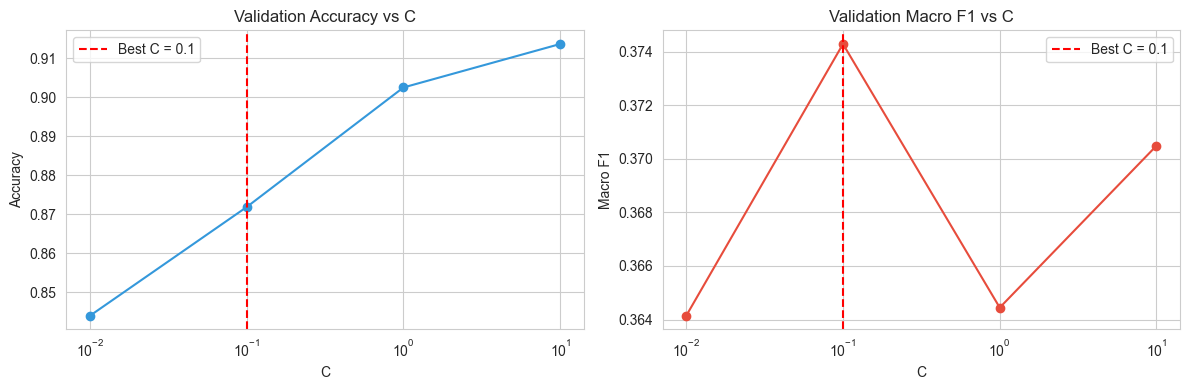

In [50]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))
axes[0].semilogx(val_df['C'], val_df['val_accuracy'], marker = 'o', color = '#3498db')
axes[0].axvline(best_C, color = 'red', linestyle = '--', label = f'Best C = {best_C}')
axes[0].set_title('Validation Accuracy vs C')
axes[0].set_xlabel('C'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].semilogx(val_df['C'], val_df['val_macro_f1'], marker = 'o', color = '#e74c3c')
axes[1].axvline(best_C, color = 'red', linestyle = '--', label = f'Best C = {best_C}')
axes[1].set_title('Validation Macro F1 vs C')
axes[1].set_xlabel('C'); axes[1].set_ylabel('Macro F1')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Final Model

In [51]:
#combine train + val for final
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

clf = LogisticRegression(
    solver = 'lbfgs',
    max_iter = 2000,
    class_weight = 'balanced',
    C = best_C,
    random_state = 42
)

final_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', clf)
])
final_pipe.fit(X_trainval.drop(columns = ['Season_End_Year']), y_trainval)

y_pred = final_pipe.predict(X_test.drop(columns = ['Season_End_Year']))
y_proba = final_pipe.predict_proba(X_test.drop(columns = ['Season_End_Year']))

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

Test accuracy: 0.9028


## 7. Metrics

In [52]:
target_names = ['Not All-NBA', '3rd Team', '2nd Team', '1st Team']
present_labels = sorted(y_test.unique())

present_names = []
for i in present_labels:
    present_names.append(target_names[i])
    
print(classification_report(y_test, y_pred, labels = present_labels, target_names = present_names))

              precision    recall  f1-score   support

 Not All-NBA       1.00      0.91      0.95       733
    3rd Team       0.10      0.44      0.16         9
    2nd Team       0.16      0.56      0.25         9
    1st Team       0.45      0.90      0.60        10

    accuracy                           0.90       761
   macro avg       0.43      0.70      0.49       761
weighted avg       0.97      0.90      0.93       761



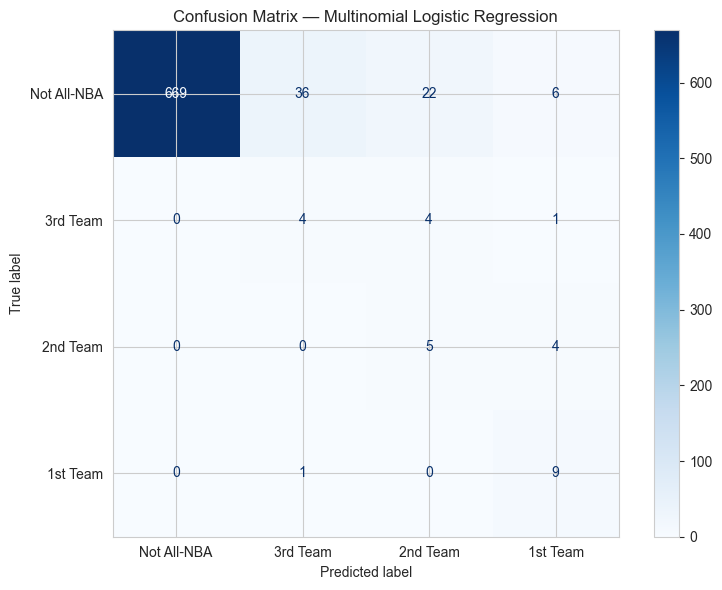

In [53]:
fig, ax = plt.subplots(figsize = (8, 6))
cm = confusion_matrix(y_test, y_pred, labels = present_labels)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = present_names)
disp.plot(ax = ax, cmap = 'Blues')

ax.set_title('Confusion Matrix — Multinomial Logistic Regression')
plt.tight_layout()
plt.show()

## 8. Project Metrics

### 8a. Any All-NBA correctness

In [56]:
y_test_bin = (y_test  > 0).astype(int)
y_pred_bin = (y_pred  > 0).astype(int)

print("Any All-NBA vs None on the test set")
print(f'Accuracy: {accuracy_score(y_test_bin, y_pred_bin):.4f}')
print(f'Precision: {precision_score(y_test_bin, y_pred_bin, zero_division = 0):.4f}')
print(f'Recall: {recall_score(y_test_bin, y_pred_bin, zero_division = 0):.4f}')
print(f'F1: {f1_score(y_test_bin, y_pred_bin, zero_division = 0):.4f}')

Any All-NBA vs None on the test set
Accuracy: 0.9159
Precision: 0.3043
Recall: 1.0000
F1: 0.4667


### 8b. Exact team accuracy 

In [58]:
allnba_mask = y_test > 0
exact_team_acc = accuracy_score(y_test[allnba_mask], y_pred[allnba_mask])

print(f"Exact team accuracy: {exact_team_acc:.4f}")

Exact team accuracy: 0.6429


### 8c. Top 15 season ranking

In [59]:
# per player test result
test_meta = df_meta[test_mask.values].reset_index(drop = True)
test_meta = test_meta.copy()

test_meta['Predicted'] = y_pred
test_meta['p_none'] = y_proba[:, 0]

test_meta['p_3rd'] = y_proba[:, 1] if y_proba.shape[1] > 1 else 0
test_meta['p_2nd'] = y_proba[:, 2] if y_proba.shape[1] > 2 else 0
test_meta['p_1st'] = y_proba[:, 3] if y_proba.shape[1] > 3 else 0

test_meta['p_any_allnba'] = 1 - test_meta['p_none']

# top 15 by season
top15_results = []
for year in sorted(test_meta['Season_End_Year'].unique()):
    season = test_meta[test_meta['Season_End_Year'] == year].copy()
    actual_set = set(season[season['All_NBA_Target'] > 0]['Player'])
    
    top15_predicted = set(season.nlargest(15, 'p_any_allnba')['Player'])
    overlap = len(actual_set & top15_predicted)
    
    results_to_add = {
        "Season" : year,
        "Overlap" : overlap,
        "Total" : len(actual_set)
    }
    top15_results.append(results_to_add)
    
    print(f"For year {year}, top 15 overlap: {overlap}/{len(actual_set)}")


For year 2024, top 15 overlap: 12/14
For year 2025, top 15 overlap: 10/14


In [60]:
top15_df = pd.DataFrame(top15_results)
print(f"Mean overlap: {top15_df["Overlap"].mean():.2f}/15")

Mean overlap: 11.00/15


## 9. Coef Table

In [64]:
clf = final_pipe.named_steps['clf']
pre = final_pipe.named_steps['pre']

cat_feature_names = pre.named_transformers_['cat'].get_feature_names_out(fit_cat_cols).tolist()
all_feature_names = cat_feature_names + fit_num_cols

index_labels = []
for i in clf.classes_:
    label = "Class " + str(i) + " (" + target_names[i] + ")"
    index_labels.append(label)    
    
coef_df = pd.DataFrame(
    clf.coef_,
    index = index_labels,
    columns = all_feature_names
).T

coef_df.head(10)

,Class 0 (Not All-NBA),Class 1 (3rd Team),Class 2 (2nd Team),Class 3 (1st Team)
Team_2TM,0.513974,-0.320998,-0.157054,-0.035923
Team_3TM,0.002041,-0.002134,-0.000039,0.000132
Team_4TM,-0.000009,0.000001,0.000004,0.000005
Team_ATL,0.309183,1.509325,-1.139414,-0.679094
Team_BOS,-0.520198,-0.155157,0.656316,0.019039
Team_BRK,0.131622,0.536105,-0.237444,-0.430284
Team_CHA,0.038479,0.355258,-0.166224,-0.227513
Team_CHI,-0.017717,-0.865701,-0.762424,1.645842
Team_CHO,0.264389,0.781822,-0.416772,-0.629439
Team_CLE,0.058773,-0.089730,0.537238,-0.506281


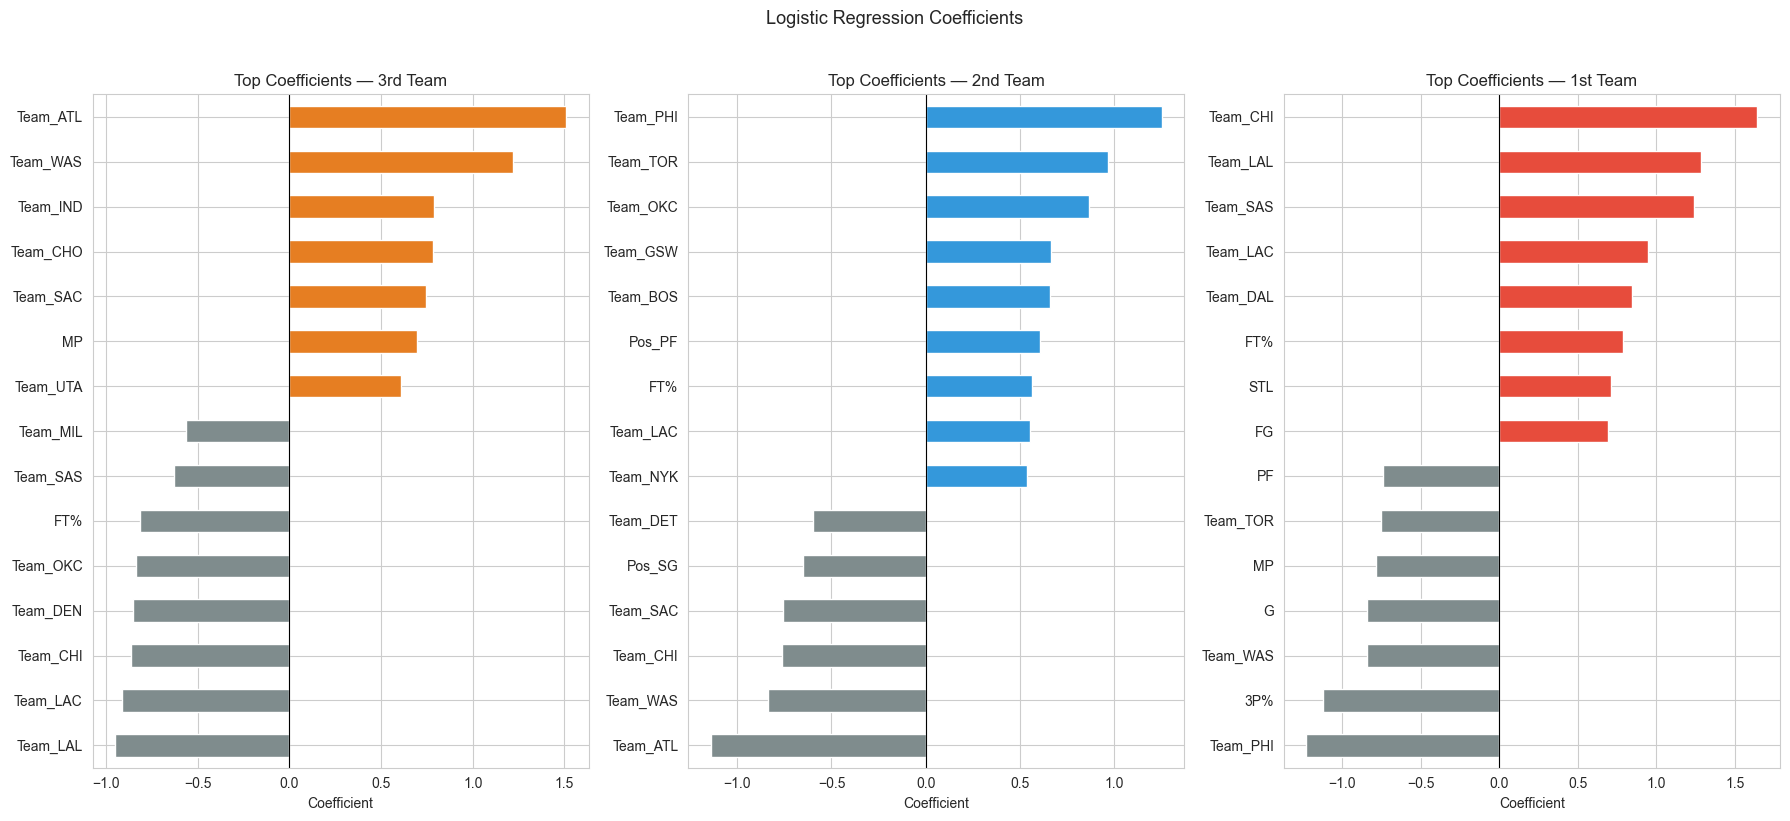

In [65]:
# top 15 by coeff magnitude
fig, axes = plt.subplots(1, 3, figsize = (18, 8))
allnba_classes = [1, 2, 3]
allnba_labels  = ['3rd Team', '2nd Team', '1st Team']
colors = ['#e67e22', '#3498db', '#e74c3c']

for ax, cls, lbl, col in zip(axes, allnba_classes, allnba_labels, colors):
    col_name = f'Class {cls} ({target_names[cls]})'
    top15 = coef_df[col_name].abs().nlargest(15)
    vals = coef_df.loc[top15.index, col_name]
    
    bar_colors = []
    for v in vals:
        if v > 0:
            bar_colors.append(col)
        else:
            bar_colors.append("#7f8c8d")
    
    sorted_vals = vals.sort_values()
    sorted_colors = []
    
    for i in sorted_vals.index:
        original_index_list = list(vals.index)
        position = original_index_list.index(i)
        sorted_colors.append(bar_colors[position])
    
    sorted_vals.plot(
        kind = 'barh',
        ax = ax,
        color = sorted_colors
    )
    
    ax.set_title(f'Top Coefficients — {lbl}')
    ax.set_xlabel('Coefficient')
    ax.axvline(0, color = 'black', linewidth = 0.8)
    
    

plt.suptitle("Logistic Regression Coefficients", fontsize = 13, y = 1.02)
plt.tight_layout()
plt.show()


## 10. Per season predictions

In [74]:
for year in sorted(test_meta['Season_End_Year'].unique()):
    year_data = test_meta[test_meta['Season_End_Year'] == year].copy()
    print("*" * 50)
    print(f'Season {year}')
    print("*" * 50)

    actual = year_data[year_data['All_NBA_Target'] > 0][['Player', 'Pos', 'All_NBA_Label', 'All_NBA_Target']]
    print(f'\nActual All-NBA ({len(actual)}):')
    print(actual.to_string(index = False))
    
    top15 = year_data.nlargest(15, 'p_any_allnba')[['Player', 'Pos', 'All_NBA_Label', 'Predicted', 'p_any_allnba', 'p_1st', 'p_2nd', 'p_3rd']].copy()
    top15['p_any_allnba'] = top15['p_any_allnba'].round(3)
    top15['p_1st'] = top15['p_1st'].round(3)
    top15['p_2nd'] = top15['p_2nd'].round(3)
    top15['p_3rd'] = top15['p_3rd'].round(3)
    
    top15['Predicted_Label'] = top15['Predicted'].map({0: 'None', 1: 'NBA3', 2: 'NBA2', 3: 'NBA1'})
    print(f'\nTop-15 by p_any_allnba:')
    print(top15.to_string(index = False))

    actual_set = set(actual['Player'])
    top15_set = set(top15['Player'])
    print(f'\nOverlap: {len(actual_set & top15_set)}/15')

**************************************************
Season 2024
**************************************************

Actual All-NBA (14):
                 Player Pos All_NBA_Label  All_NBA_Target
  Giannis Antetokounmpo  PF          NBA1               3
           Devin Booker  PG          NBA3               1
          Jalen Brunson  PG          NBA2               2
          Stephen Curry  PG          NBA3               1
          Anthony Davis   C          NBA2               2
            Luka Dončić  PG          NBA1               3
           Kevin Durant  PF          NBA2               2
        Anthony Edwards  SG          NBA2               2
Shai Gilgeous-Alexander  PG          NBA1               3
      Tyrese Haliburton  PG          NBA3               1
           Nikola Jokić   C          NBA1               3
          Kawhi Leonard  SF          NBA2               2
       Domantas Sabonis   C          NBA3               1
           Jayson Tatum  PF          NBA1           

## Comparison

In [75]:
#FULL PIPELINE, like this is it all together

def run_logistic_pipeline(dataset_path, dataset_name):
    df_d = pd.read_csv(dataset_path)
    
    d_cat = []
    possible_cat_cols = ["Team", "Pos"]
    
    for col in possible_cat_cols:
        if col in df_d.columns:
            d_cat.append(col)
            
            
    d_num = []
    for col in df_d.columns:
        if col not in d_cat and col != "All_NBA_Target":
            d_num.append(col)
            
    d_fit_num = []
    for col in d_num:
        if col != "Season_End_Year":
            d_fit_num.append(col)
            
            
            
    cat_transformer = OneHotEncoder(handle_unknown = "ignore", sparse_output = False)
    
    num_transformer = Pipeline([
        ("impute", SimpleImputer(strategy = "median")),
        ("scale", StandardScaler())
    ])
    
    transformers = [] 
    if d_cat:
        transformers.append(('cat', cat_transformer, d_cat))

    transformers.append(('num', num_transformer, d_fit_num))
    d_pre = ColumnTransformer(transformers = transformers, remainder = "drop")        
    
    if not d_cat:
        d_pre = Pipeline([
            ("impute", SimpleImputer(strategy = "median")),
            ("scale",  StandardScaler())
        ])
        
    feat_cols_d = []
    for col in df_d.columns:
        if col != "All_NBA_Target":
            feat_cols_d.append(col)
            
    X_d = df_d[feat_cols_d]
    y_d = df_d["All_NBA_Target"]

    tr = df_d["Season_End_Year"] <= 2022
    va = df_d["Season_End_Year"] == 2023
    te = df_d["Season_End_Year"] >= 2024

    X_d_feat = X_d.drop(columns = ["Season_End_Year"])
    
    best_c = None
    best_f1 = -1
    
    C_values = [0.01, 0.1, 1.0, 10.0]
    
    for C in C_values:
        clf = LogisticRegression(
            solver = 'lbfgs',
            max_iter = 2000,
            class_weight = 'balanced',
            C = C,
            random_state = 42
        )

        pipe_d = Pipeline([
            ('pre', d_pre),
            ('clf', clf)
        ])

        pipe_d.fit(X_d_feat[tr], y_d[tr])
        preds = pipe_d.predict(X_d_feat[va])

        val_f1 = f1_score(
            y_d[va],
            preds,
            average = 'macro',
            zero_division = 0
        )

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_c = C
            
    
    tv = tr | va
    clf = LogisticRegression(
        solver = 'lbfgs',
        max_iter = 2000,
        class_weight = 'balanced',
        C = best_c,
        random_state = 42
    )

    pipe_final = Pipeline([
        ('pre', d_pre),
        ('clf', clf)
    ])

    pipe_final.fit(X_d_feat[tv], y_d[tv])
    
    y_pred_d  = pipe_final.predict(X_d_feat[te])
    y_proba_d = pipe_final.predict_proba(X_d_feat[te])
    
    acc = accuracy_score(y_d[te], y_pred_d)
    mf1 = f1_score(y_d[te], y_pred_d, average = 'macro', zero_division = 0)
    
    
    # top 15 overlap
    test_meta_d = df_meta[te.values].reset_index(drop = True).copy()
    test_meta_d['p_any_allnba'] = 1 - y_proba_d[:, 0]
    overlaps = []
    
    for year in sorted(test_meta_d['Season_End_Year'].unique()):
        yd = test_meta_d[test_meta_d['Season_End_Year'] == year]
        
        actual_s = set(yd[yd['All_NBA_Target'] > 0]['Player'])
        top15_s = set(yd.nlargest(15, 'p_any_allnba')['Player'])
        
        overlaps.append(len(actual_s & top15_s))
        
    mean_overlap = np.mean(overlaps)
    
    
    print("*" * 50)
    print(f"Dataset: {dataset_name}, best C = {best_c}")
    print(f"Test accuracy: {acc:.4f}")
    print(f"Test macro F1: {mf1:.4f}")
    print(f"Mean top-15 overlap: {mean_overlap:.2f}/15")
    
    labels = sorted(y_d[te].unique())

    team_names = ['Not All-NBA', '3rd Team', '2nd Team', '1st Team']

    target_names = []
    for i in labels:
        target_names.append(team_names[i])

    report = classification_report(
        y_d[te],
        y_pred_d,
        labels = labels,
        target_names = target_names,
        zero_division = 0
    )
    print(report)
    
    
    final_data = {
        "dataset" : dataset_name,
        "accuracy" : acc,
        "macro_f1" : mf1,
        "mean_top15_overlap" : mean_overlap,
        "best_C" : best_c
    }
    
    return final_data


results = []
results.append(run_logistic_pipeline("data/model_datasets/basic_dataset.csv", "basic"))
results.append(run_logistic_pipeline("data/model_datasets/advanced_dataset.csv", "advanced"))
results.append(run_logistic_pipeline("data/model_datasets/hybrid_trimmed_dataset.csv", "hybrid_trimmed"))
        

**************************************************
Dataset: basic, best C = 0.1
Test accuracy: 0.9028
Test macro F1: 0.4911
Mean top-15 overlap: 11.00/15
              precision    recall  f1-score   support

 Not All-NBA       1.00      0.91      0.95       733
    3rd Team       0.10      0.44      0.16         9
    2nd Team       0.16      0.56      0.25         9
    1st Team       0.45      0.90      0.60        10

    accuracy                           0.90       761
   macro avg       0.43      0.70      0.49       761
weighted avg       0.97      0.90      0.93       761

**************************************************
Dataset: advanced, best C = 10.0
Test accuracy: 0.9606
Test macro F1: 0.5789
Mean top-15 overlap: 11.50/15
              precision    recall  f1-score   support

 Not All-NBA       1.00      0.98      0.99       733
    3rd Team       0.24      0.56      0.33         9
    2nd Team       0.31      0.44      0.36         9
    1st Team       0.67      0.60   

In [76]:
# Summary comparison table

summary = pd.DataFrame(results)
summary = summary.set_index("dataset")
summary

,accuracy,macro_f1,mean_top15_overlap,best_C
dataset,,,,
basic,0.902760,0.491088,11.0,0.10
advanced,0.960578,0.578864,11.5,10.00
hybrid_trimmed,0.902760,0.466856,12.0,0.01


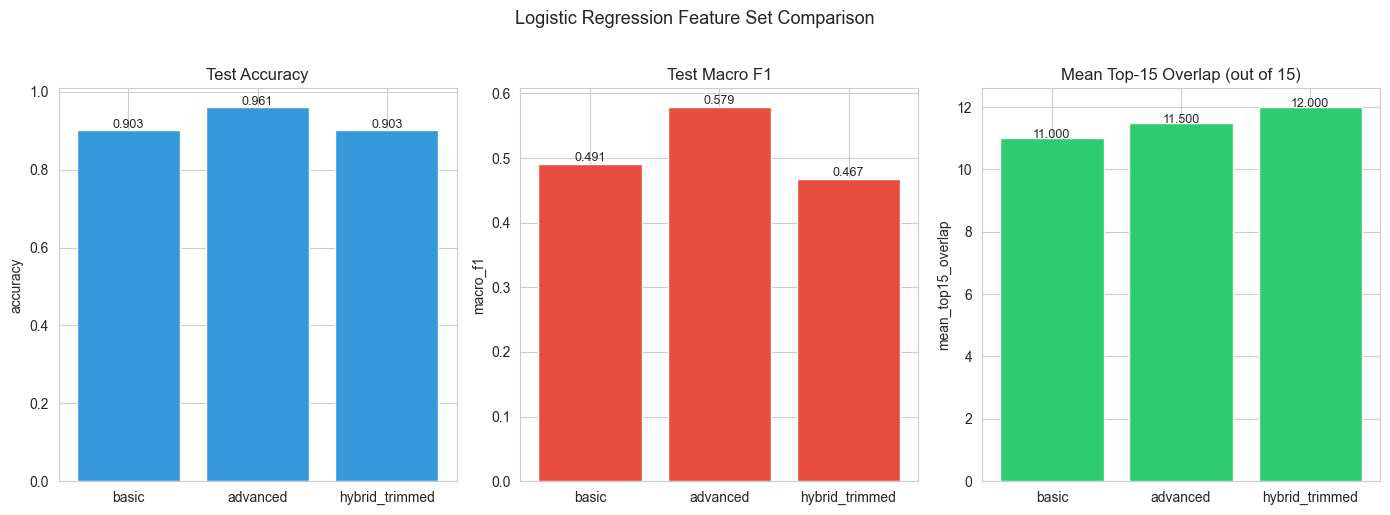

In [78]:
fig, axes = plt.subplots(1, 3, figsize = (14, 5))

metrics = ['accuracy', 'macro_f1', 'mean_top15_overlap']
titles  = ['Test Accuracy', 'Test Macro F1', 'Mean Top-15 Overlap (out of 15)']
palette = ['#3498db', '#e74c3c', '#2ecc71']

for ax, m, t, c in zip(axes, metrics, titles, palette):
    ax.bar(summary.index, summary[m], color = c)
    ax.set_title(t)
    ax.set_ylabel(m)
    
    for i, v in enumerate(summary[m]):
        ax.text(i, v + 0.005, f'{v:.3f}', ha = 'center', fontsize = 9)

plt.suptitle('Logistic Regression Feature Set Comparison', fontsize = 13, y = 1.02)
plt.tight_layout()
plt.show()

## 12. Save to CSV

In [79]:
os.makedirs('outputs', exist_ok=True)

out_df = test_meta.copy()

out_df['p_none'] = y_proba[:, 0].round(4)

out_df['p_3rd'] = y_proba[:, 1].round(4) if y_proba.shape[1] > 1 else 0
out_df['p_2nd'] = y_proba[:, 2].round(4) if y_proba.shape[1] > 2 else 0
out_df['p_1st'] = y_proba[:, 3].round(4) if y_proba.shape[1] > 3 else 0

out_df['p_any_allnba'] = (1 - out_df['p_none']).round(4)
out_df['Predicted'] = y_pred
out_df['Correct'] = (out_df['Predicted'] == out_df['All_NBA_Target']).astype(int)

out_df.to_csv('outputs/logistic_regression_test_predictions.csv', index = False)
out_df[out_df['All_NBA_Target'] > 0].sort_values(['Season_End_Year', 'All_NBA_Target'], ascending = [True, False])

,Player,Team,Pos,Season_End_Year,All_NBA_Label,All_NBA_Target,Predicted,p_none,p_3rd,p_2nd,p_1st,p_any_allnba,Correct
9,Giannis Antetokounmpo,MIL,PF,2024,NBA1,3,3,0.0000,0.0119,0.4220,0.5661,1.0000,1
83,Luka Dončić,DAL,PG,2024,NBA1,3,3,0.0000,0.0014,0.0052,0.9934,1.0000,1
114,Shai Gilgeous-Alexander,OKC,PG,2024,NBA1,3,3,0.0000,0.0021,0.0601,0.9379,1.0000,1
175,Nikola Jokić,DEN,C,2024,NBA1,3,3,0.0000,0.0050,0.1225,0.8725,1.0000,1
313,Jayson Tatum,BOS,PF,2024,NBA1,3,3,0.0005,0.0718,0.3808,0.5470,0.9995,1
49,Jalen Brunson,NYK,PG,2024,NBA2,2,2,0.0002,0.1382,0.7322,0.1294,0.9998,1
78,Anthony Davis,LAL,C,2024,NBA2,2,3,0.0000,0.0013,0.0292,0.9695,1.0000,0
89,Kevin Durant,PHO,PF,2024,NBA2,2,2,0.0001,0.0520,0.6894,0.2586,0.9999,1
92,Anthony Edwards,MIN,SG,2024,NBA2,2,3,0.0020,0.2288,0.1450,0.6242,0.9980,0
193,Kawhi Leonard,LAC,SF,2024,NBA2,2,3,0.0019,0.1102,0.4059,0.4820,0.9981,0
